# Stellar Classification using Machine Learning

## Objective

The objective of this project is to develop and compare multiple machine learning classification models for predicting the type of celestial object based on astronomical observations.

The dataset contains observations from the Sloan Digital Sky Survey (SDSS), where each observation belongs to one of the following classes:

- STAR
- GALAXY
- QSO (Quasi-Stellar Object)

The following machine learning algorithms will be implemented and evaluated:

1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbors (KNN)
4. Gaussian Naive Bayes
5. Random Forest Classifier

Each model will be evaluated using:

- Accuracy
- AUC Score
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

Finally, all models will be compared to identify the best-performing classifier.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Save Models
import joblib

# Display Options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("star_classification.csv")

print("Dataset loaded successfully!\n")

print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!

Dataset Shape: (100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [3]:
# ==========================================================
# Dataset Information
# ==========================================================

print("Shape of Dataset:", df.shape)
print("\nColumn Names:\n")
print(df.columns.tolist())

print("\nData Types:\n")
print(df.dtypes)

print("\nDataset Information:\n")
df.info()

Shape of Dataset: (100000, 18)

Column Names:

['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']

Data Types:

obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class           object
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64


In [4]:
# ==========================================================
# Summary Statistics
# ==========================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,1.237665e+18,8.438560e+12,1.237646e+18,1.237659e+18,1.237663e+18,1.237668e+18,1.237681e+18
alpha,100000.0,1.776291e+02,9.650224e+01,5.527828e-03,1.275182e+02,1.809007e+02,2.338950e+02,3.599998e+02
delta,100000.0,2.413530e+01,1.964467e+01,-1.878533e+01,5.146771e+00,2.364592e+01,3.990155e+01,8.300052e+01
u,100000.0,2.198047e+01,3.176929e+01,-9.999000e+03,2.035235e+01,2.217914e+01,2.368744e+01,3.278139e+01
g,100000.0,2.053139e+01,3.175029e+01,-9.999000e+03,1.896523e+01,2.109983e+01,2.212377e+01,3.160224e+01
r,100000.0,1.964576e+01,1.854760e+00,9.822070e+00,1.813583e+01,2.012529e+01,2.104478e+01,2.957186e+01
i,100000.0,1.908485e+01,1.757895e+00,9.469903e+00,1.773228e+01,1.940514e+01,2.039650e+01,3.214147e+01
z,100000.0,1.866881e+01,3.172815e+01,-9.999000e+03,1.746068e+01,1.900460e+01,1.992112e+01,2.938374e+01
run_ID,100000.0,4.481366e+03,1.964765e+03,1.090000e+02,3.187000e+03,4.188000e+03,5.326000e+03,8.162000e+03
rerun_ID,100000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


In [5]:
# ==========================================================
# Missing Values
# ==========================================================

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

Total Missing Values: 0


In [6]:
# ==========================================================
# Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


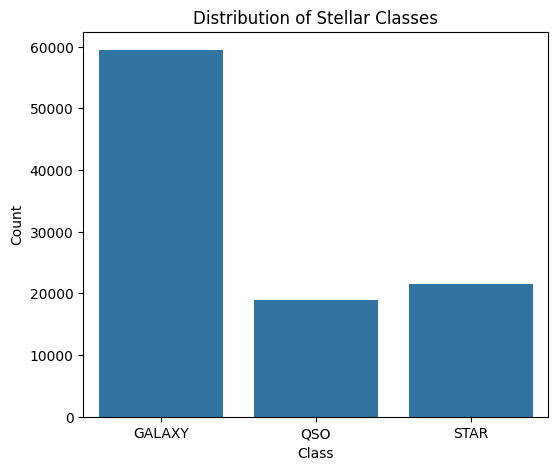

In [7]:
# ==========================================================
# Class Distribution
# ==========================================================

print(df["class"].value_counts())

plt.figure(figsize=(6,5))

sns.countplot(data=df, x="class")

plt.title("Distribution of Stellar Classes")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [8]:
# ==========================================================
# Unique Values
# ==========================================================

df.nunique().sort_values()

,0
rerun_ID,1
class,3
cam_col,6
run_ID,430
field_ID,856
fiber_ID,1000
MJD,2180
plate,6284
obj_ID,78053
r,91901


In [9]:
df.info()
df.describe().T
df.nunique()
df["class"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

,count
class,
GALAXY,59445
STAR,21594
QSO,18961


In [10]:
df.nunique().sort_values()

,0
rerun_ID,1
class,3
cam_col,6
run_ID,430
field_ID,856
fiber_ID,1000
MJD,2180
plate,6284
obj_ID,78053
r,91901


## Data Preprocessing

Before training the machine learning models, the dataset is preprocessed to improve model performance and remove non-informative features.

The following preprocessing steps are performed:

- **`obj_ID`** is removed because it is a unique identifier assigned to each astronomical object and does not represent any physical characteristic of the object.
- **`spec_obj_ID`** is removed because it is a unique spectroscopic object identifier. Using this feature may introduce data leakage since different observations of the same object share the same identifier.
- **`rerun_ID`** is removed because it contains only a single unique value throughout the dataset, making it a constant feature with no predictive value.

The remaining features either describe the physical properties of celestial objects (such as photometric magnitudes and redshift) or provide observational metadata that may contribute to the classification task.

In [11]:
# ==========================================================
# Drop Non-Informative Features
# ==========================================================

columns_to_drop = ["obj_ID", "spec_obj_ID", "rerun_ID"]

df = df.drop(columns=columns_to_drop)

print("Dropped Columns:")
print(columns_to_drop)

print("\nUpdated Dataset Shape:", df.shape)

Dropped Columns:
['obj_ID', 'spec_obj_ID', 'rerun_ID']

Updated Dataset Shape: (100000, 15)


## Label Encoding

The target variable **class** contains three categorical labels:

- GALAXY
- QSO
- STAR

Machine learning algorithms require numerical labels for training. Therefore, the target variable is converted into integer values using **Label Encoding**.

The mapping generated by the encoder is displayed for reference.

In [12]:
# ==========================================================
# Encode Target Variable
# ==========================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["class"] = label_encoder.fit_transform(df["class"])

print("Class Label Mapping:\n")

for index, label in enumerate(label_encoder.classes_):
    print(f"{label} --> {index}")

Class Label Mapping:

GALAXY --> 0
QSO --> 1
STAR --> 2


## Feature and Target Separation

The dataset is divided into:

- **Feature Matrix (X):** All input variables used for prediction.
- **Target Vector (y):** The encoded class labels representing the celestial object category.

This separation is required before splitting the dataset into training and testing sets.

In [13]:
# ==========================================================
# Separate Features and Target
# ==========================================================

X = df.drop("class", axis=1)
y = df["class"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (100000, 14)
Target Vector Shape  : (100000,)


## Train-Test Split

The dataset is divided into training and testing sets to evaluate the performance of the machine learning models on unseen data.

A stratified split is used to preserve the original class distribution in both the training and testing datasets.

- Training Set: 80%
- Testing Set: 20%
- Random State: 42
- Stratification: Enabled

In [14]:
# ==========================================================
# Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)

print("Training Target Shape  :", y_train.shape)
print("Testing Target Shape   :", y_test.shape)

Training Feature Shape : (80000, 14)
Testing Feature Shape  : (20000, 14)
Training Target Shape  : (80000,)
Testing Target Shape   : (20000,)


## Feature Scaling

Feature scaling standardizes numerical features so that they have a mean of zero and a standard deviation of one.

This preprocessing step improves the performance of algorithms that are sensitive to the scale of the data, such as:

- Logistic Regression
- K-Nearest Neighbors (KNN)

Tree-based algorithms such as Decision Tree and Random Forest, as well as Gaussian Naive Bayes, are trained using the original (unscaled) feature values.

In [15]:
# ==========================================================
# Feature Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

print("\nScaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

Feature scaling completed successfully.

Scaled Training Shape : (80000, 14)
Scaled Testing Shape  : (20000, 14)


# Model Evaluation Function

To ensure consistency across all machine learning models, a reusable evaluation function is created.

The function performs the following tasks:

- Generates predictions on the test dataset.
- Calculates the required evaluation metrics.
- Displays the confusion matrix.
- Prints the classification report.
- Stores the evaluation results for later comparison.

The following evaluation metrics are computed:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Matthews Correlation Coefficient (MCC)

This approach avoids code duplication and provides a standardized evaluation framework for all classifiers.

In [16]:
# ==========================================================
# Dictionary to Store Model Results
# ==========================================================

results = {}

In [17]:
# ==========================================================
# Model Evaluation Function
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


def evaluate_model(model_name, model, X_test, y_test):

    # Prediction
    y_pred = model.predict(X_test)

    # Probability Scores (for ROC-AUC)
    y_prob = model.predict_proba(X_test)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )
    mcc = matthews_corrcoef(y_test, y_pred)

    # Store Results
    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc,
        "MCC": mcc
    }

    # Print Metrics
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")
    print(f"MCC      : {mcc:.4f}")

    # Classification Report
    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred),
        display_labels=label_encoder.classes_
    )

    disp.plot(cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

# Logistic Regression

Logistic Regression is a linear classification algorithm that estimates the probability of each class using the logistic (softmax) function.

Since Logistic Regression is sensitive to feature scales, the standardized dataset is used for training.

The trained model is evaluated using the predefined evaluation function.

Logistic Regression
Accuracy : 0.9576
Precision: 0.9576
Recall   : 0.9576
F1 Score : 0.9571
AUC      : 0.9863
MCC      : 0.9248

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.97      0.96     11889
           1       0.96      0.88      0.92      3792
           2       0.95      1.00      0.97      4319

    accuracy                           0.96     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000



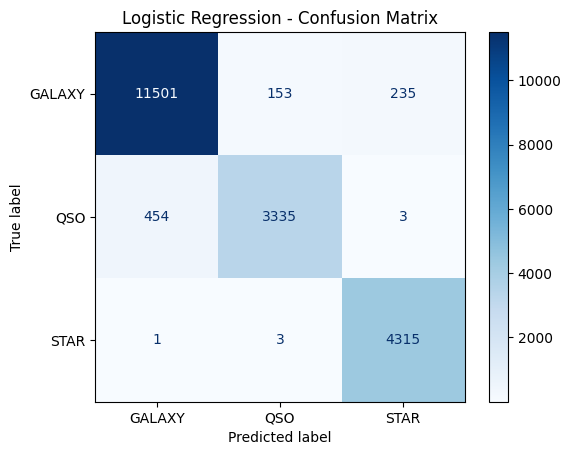

In [18]:
# ==========================================================
# Logistic Regression
# ==========================================================

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test_scaled,
    y_test
)

# Decision Tree Classifier

Decision Tree is a non-linear supervised learning algorithm that recursively partitions the feature space into decision regions based on feature values.

Unlike Logistic Regression, Decision Tree does not require feature scaling because it makes decisions using threshold-based splits.

The model is trained using the original feature values and evaluated using the common evaluation framework.

Decision Tree
Accuracy : 0.9673
Precision: 0.9673
Recall   : 0.9673
F1 Score : 0.9673
AUC      : 0.9699
MCC      : 0.9420

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     11889
           1       0.92      0.92      0.92      3792
           2       1.00      1.00      1.00      4319

    accuracy                           0.97     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.97      0.97      0.97     20000



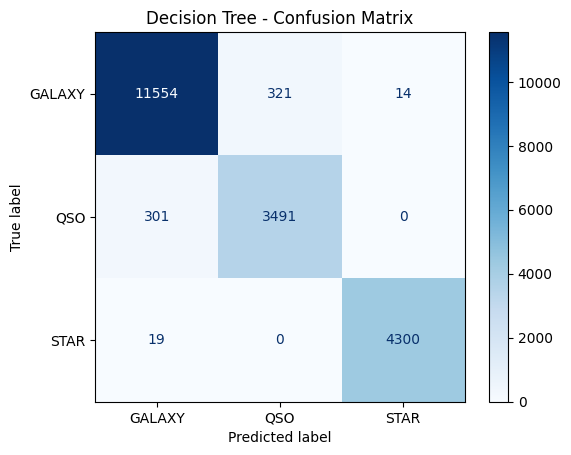

In [19]:
# ==========================================================
# Decision Tree Classifier
# ==========================================================

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_test,
    y_test
)

# K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a non-parametric, instance-based learning algorithm that classifies a sample based on the majority class among its nearest neighbors.

Since KNN relies on distance calculations, feature scaling is essential. Therefore, the standardized training and testing datasets are used for model training and evaluation.

The model is configured with **k = 5**, which is a common default choice for multiclass classification problems.

K-Nearest Neighbors
Accuracy : 0.9032
Precision: 0.9060
Recall   : 0.9032
F1 Score : 0.9019
AUC      : 0.9498
MCC      : 0.8258

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.96      0.92     11889
           1       0.97      0.83      0.89      3792
           2       0.91      0.80      0.85      4319

    accuracy                           0.90     20000
   macro avg       0.92      0.86      0.89     20000
weighted avg       0.91      0.90      0.90     20000



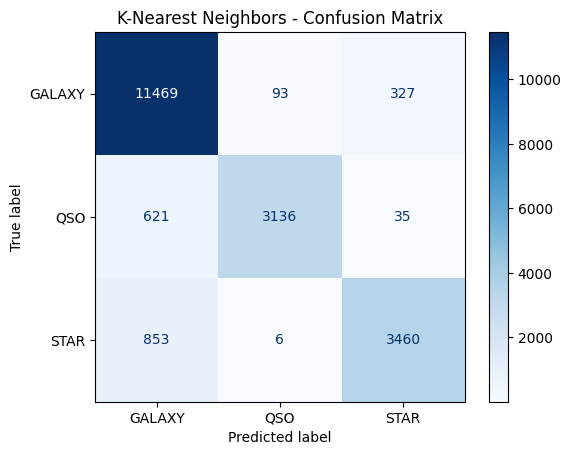

In [20]:
# ==========================================================
# K-Nearest Neighbors (KNN)
# ==========================================================

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

evaluate_model(
    "K-Nearest Neighbors",
    knn_model,
    X_test_scaled,
    y_test
)

# Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem. It assumes that the features are conditionally independent given the target class and that numerical features follow a Gaussian (normal) distribution.

Although the independence assumption is often violated in real-world datasets, Gaussian Naive Bayes is computationally efficient and serves as a useful baseline classifier.

The model is trained using the original feature values and evaluated using the common evaluation framework.

Gaussian Naive Bayes
Accuracy : 0.6911
Precision: 0.6492
Recall   : 0.6911
F1 Score : 0.6181
AUC      : 0.7947
MCC      : 0.4366

Classification Report

              precision    recall  f1-score   support

           0       0.72      0.87      0.79     11889
           1       0.62      0.89      0.73      3792
           2       0.48      0.03      0.05      4319

    accuracy                           0.69     20000
   macro avg       0.61      0.59      0.52     20000
weighted avg       0.65      0.69      0.62     20000



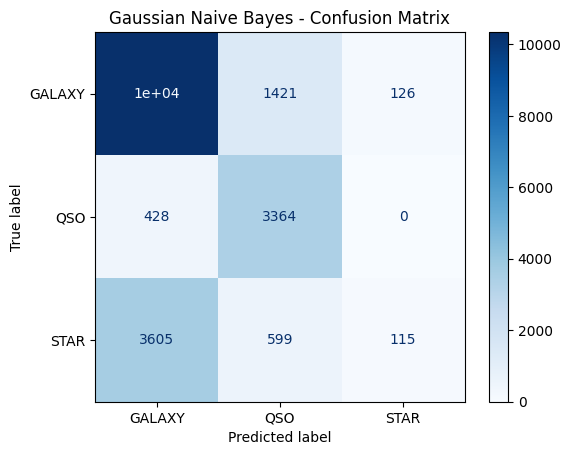

In [21]:
# ==========================================================
# Gaussian Naive Bayes
# ==========================================================

naive_bayes_model = GaussianNB()

naive_bayes_model.fit(X_train, y_train)

evaluate_model(
    "Gaussian Naive Bayes",
    naive_bayes_model,
    X_test,
    y_test
)

# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve classification performance and reduce overfitting.

Each tree is trained on a random subset of the training data and features. The final prediction is obtained through majority voting across all trees.

Random Forest generally provides better generalization than a single Decision Tree while maintaining high predictive accuracy.

Random Forest
Accuracy : 0.9794
Precision: 0.9793
Recall   : 0.9794
F1 Score : 0.9792
AUC      : 0.9948
MCC      : 0.9633

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11889
           1       0.97      0.93      0.95      3792
           2       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



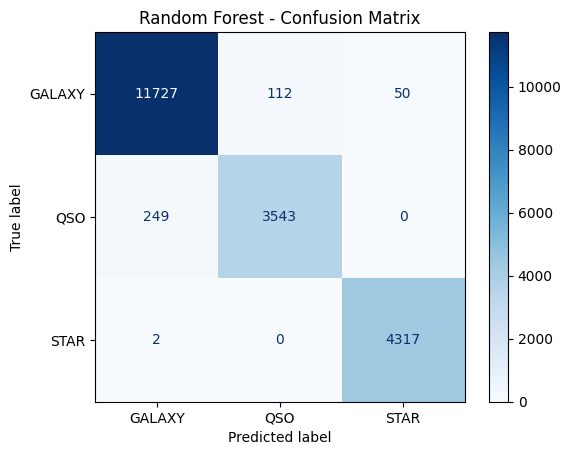

In [22]:
# ==========================================================
# Random Forest Classifier
# ==========================================================

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)

# Model Performance Analysis

Five machine learning classification algorithms were trained and evaluated on the Stellar Classification dataset.

## Observations

- **Random Forest** achieved the best overall performance across all evaluation metrics, with an accuracy of **97.94%** and an AUC of **99.48%**. Its ensemble learning approach provided excellent generalization and robust classification performance.

- **Decision Tree** produced strong results with an accuracy of **96.73%**, outperforming Logistic Regression in Accuracy, F1 Score, and MCC. However, Random Forest further improved performance by reducing overfitting through ensemble learning.

- **Logistic Regression** performed remarkably well for a linear model, achieving an accuracy of **95.76%** and a high AUC of **98.63%**, indicating good probability estimation.

- **K-Nearest Neighbors (KNN)** achieved an accuracy of **90.32%**. Although it classified GALAXY objects effectively, its performance decreased for QSO and STAR classes due to overlapping feature distributions.

- **Gaussian Naive Bayes** produced the lowest performance with an accuracy of **69.11%**. The independence assumption between features is likely violated in this dataset, resulting in poor classification, particularly for the STAR class.

## Best Model

Based on Accuracy, Precision, Recall, F1 Score, AUC, and MCC, **Random Forest** is selected as the best-performing model for the Stellar Classification dataset.

In [23]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison_df = (
    pd.DataFrame(results)
    .T
    .round(4)
    .sort_values(by="Accuracy", ascending=False)
)

comparison_df

,Accuracy,Precision,Recall,F1 Score,AUC,MCC
Random Forest,0.9794,0.9793,0.9794,0.9792,0.9948,0.9633
Decision Tree,0.9672,0.9673,0.9672,0.9673,0.9699,0.9420
Logistic Regression,0.9576,0.9576,0.9576,0.9571,0.9863,0.9248
K-Nearest Neighbors,0.9032,0.9060,0.9032,0.9019,0.9498,0.8258
Gaussian Naive Bayes,0.6911,0.6492,0.6911,0.6181,0.7947,0.4366


# Feature Importance Analysis

Random Forest provides a feature importance score that estimates how much each feature contributes to the classification process.

Features with higher importance values have a greater influence on the model's predictions.

Analyzing feature importance helps identify the most informative astronomical measurements for distinguishing between Stars, Galaxies, and Quasars.

In [24]:
# ==========================================================
# Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,redshift,0.575752
6,z,0.083093
3,g,0.064233
2,u,0.061946
5,i,0.058317
11,plate,0.040937
4,r,0.037823
12,MJD,0.032154
1,delta,0.010571
0,alpha,0.010344


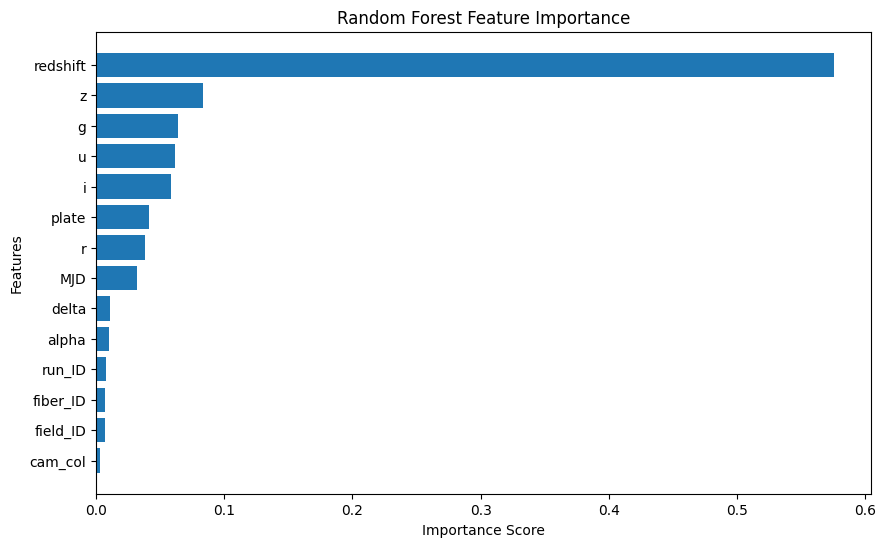

In [25]:
# ==========================================================
# Feature Importance Plot
# ==========================================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

## Observations

The Random Forest model identified several features as highly influential in classifying celestial objects.

Features such as **redshift**, **u**, **g**, **r**, and **z** contributed significantly to the prediction process. These features represent important astronomical measurements that help distinguish Stars, Galaxies, and Quasars.

Observation metadata features showed comparatively lower importance, indicating that the physical characteristics of celestial objects are more informative than observational identifiers.

Overall, the feature importance analysis demonstrates that the model primarily relies on scientifically meaningful measurements rather than dataset-specific identifiers.

# Save Test Dataset

The testing dataset is saved as a CSV file.

This file will be used in the Streamlit application for evaluating the trained machine learning models on unseen data.

In [26]:
# ==========================================================
# Save Test Dataset
# ==========================================================

test_data = X_test.copy()
test_data["class"] = y_test

test_data.to_csv("test_data.csv", index=False)

print("test_data.csv saved successfully.")
test_data.head()

test_data.csv saved successfully.


,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,redshift,plate,MJD,fiber_ID,class
33708,215.764845,0.091149,21.76577,20.69971,20.60803,20.04432,19.86779,752,4,482,-0.000497,4028,55621,658,2
64005,114.272974,40.171527,22.92180,23.10917,21.28561,20.13262,19.29569,1402,5,52,0.604732,9369,58054,717,0
66535,157.233778,38.882164,22.71756,21.46653,21.65581,22.05357,21.37843,3647,3,124,0.034463,4558,55569,202,0
27072,243.238987,43.901251,20.97291,18.69353,17.73737,17.27101,16.99122,3226,6,66,0.141547,814,52443,284,0
26350,240.587697,45.858450,24.12886,21.30253,19.44458,18.73669,18.27479,3226,6,47,0.424649,6033,56069,920,0


In [27]:
# ==========================================================
# Save Trained Models
# ==========================================================

joblib.dump(logistic_model, "logistic_regression.pkl")
joblib.dump(decision_tree_model, "decision_tree.pkl")
joblib.dump(knn_model, "knn.pkl")
joblib.dump(naive_bayes_model, "gaussian_nb.pkl")
joblib.dump(random_forest_model, "random_forest.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

# Save the label encoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("All models saved successfully.")

All models saved successfully.


# Conclusion

In this project, five supervised machine learning algorithms were implemented and compared for stellar object classification using the SDSS17 Stellar Classification dataset.

The models were evaluated using Accuracy, Precision, Recall, F1 Score, ROC-AUC, and Matthews Correlation Coefficient (MCC).

Among all the classifiers, **Random Forest** achieved the best overall performance, obtaining the highest Accuracy, F1 Score, ROC-AUC, and MCC. The ensemble approach of Random Forest effectively captured the complex relationships between astronomical features, leading to superior predictive performance.

Logistic Regression and Decision Tree also demonstrated strong classification capabilities, while K-Nearest Neighbors and Gaussian Naive Bayes produced comparatively lower performance.

The results indicate that ensemble-based methods are highly effective for multiclass stellar classification problems and provide reliable predictions for distinguishing between Stars, Galaxies, and Quasars.